<a href="https://colab.research.google.com/github/AmalKhairalla/Online-News-Popularity/blob/main/Task%20A%20%E2%80%94%20Classification/Logistic_Regression_(L1_L2_regularization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
from google.colab import drive
drive.mount('/content/drive')

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SAVE_PATH = "/content/drive/MyDrive/ML_Project_Classification"

X_train_scaled = joblib.load(f"{SAVE_PATH}/X_train_scaled.pkl")
X_test_scaled = joblib.load(f"{SAVE_PATH}/X_test_scaled.pkl")
y_train = joblib.load(f"{SAVE_PATH}/y_train.pkl")
y_test = joblib.load(f"{SAVE_PATH}/y_test.pkl")

print("Loaded successfully!")
print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded successfully!
X_train: (31715, 15)
X_test: (7929, 15)
y_train: (31715,)
y_test: (7929,)


##Classification Target

In [70]:
median_shares = df_winsorized['shares'].median()

df_winsorized['popular'] = (
    df_winsorized['shares'] > median_shares
).astype(int)

print(df_winsorized['popular'].value_counts())

popular
0    20082
1    19562
Name: count, dtype: int64


##Remove Leakage Columns

In [71]:
leakage_cols = [
    'shares',
    'log_shares',
    'sentiment_engagement_score',
    'url',
    'popular'
]

existing_cols = [
    col for col in leakage_cols
    if col in df_winsorized.columns
]

X = df_winsorized.drop(columns=existing_cols)

y = df_winsorized['popular']

##Use RFE Features Only

In [72]:
X = X[rfe_features]

print(X.shape)
print(y.shape)

(39644, 15)
(39644,)


##Train/Test Split + Scaling

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###1.Logistic Regression (L1/L2 regularization)


========== Logistic Regression L2 Baseline ==========
              precision    recall  f1-score   support

           0       0.64      0.63      0.63      4017
           1       0.62      0.63      0.63      3912

    accuracy                           0.63      7929
   macro avg       0.63      0.63      0.63      7929
weighted avg       0.63      0.63      0.63      7929

                             Model  Accuracy  Precision    Recall  F1-score  \
0  Logistic Regression L2 Baseline  0.630092   0.622836  0.634458  0.628593   

    ROC-AUC    PR-AUC  Brier Score       MCC  
0  0.670284  0.655394     0.228099  0.260279  

========== Logistic Regression L1 Baseline ==========
              precision    recall  f1-score   support

           0       0.64      0.63      0.63      4017
           1       0.62      0.63      0.63      3912

    accuracy                           0.63      7929
   macro avg       0.63      0.63      0.63      7929
weighted avg       0.63      0.63     

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Brier Score,MCC
0,Logistic Regression L2 Baseline,0.630092,0.622836,0.634458,0.628593,0.670284,0.655394,0.228099,0.260279
1,Logistic Regression L1 Baseline,0.629461,0.622362,0.633180,0.627724,0.670299,0.655456,0.228093,0.258999


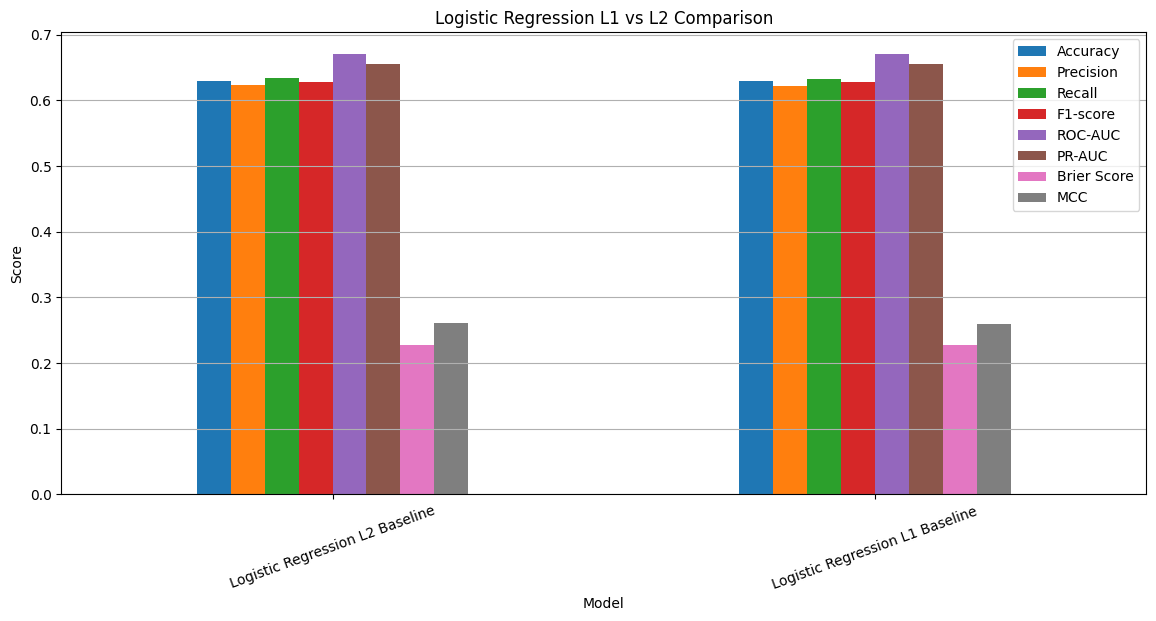

In [74]:
# ============================================================
# Logistic Regression L1/L2 Complete Section
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    learning_curve,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    matthews_corrcoef,
    brier_score_loss
)
from sklearn.calibration import CalibrationDisplay
from scipy.stats import loguniform


# ============================================================
# 1) Evaluation Function
# ============================================================

def evaluate_classifier(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba),
        "Brier Score": brier_score_loss(y_test, y_proba),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

    print(f"\n========== {model_name} ==========")
    print(classification_report(y_test, y_pred))
    print(pd.DataFrame([results]))

    return results


# ============================================================
# 2) Logistic Regression L2 Baseline
# ============================================================

log_l2 = Pipeline([

    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=0.1,
        max_iter=5000,
        random_state=42
    ))
])

log_l2.fit(X_train_scaled, y_train)
results_l2 = evaluate_classifier(log_l2, X_test_scaled, y_test, "Logistic Regression L2 Baseline")


# ============================================================
# 3) Logistic Regression L1 Baseline
# ============================================================

log_l1 = Pipeline([

    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

log_l1.fit(X_train_scaled, y_train)
results_l1 = evaluate_classifier(log_l1, X_test_scaled, y_test, "Logistic Regression L1 Baseline")


# ============================================================
# 4) Compare L1 vs L2
# ============================================================

comparison_df = pd.DataFrame([results_l2, results_l1])
display(comparison_df)

comparison_df.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC", "Brier Score", "MCC"
]].plot(kind="bar", figsize=(14, 6))

plt.title("Logistic Regression L1 vs L2 Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

##Confusion Matrix

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


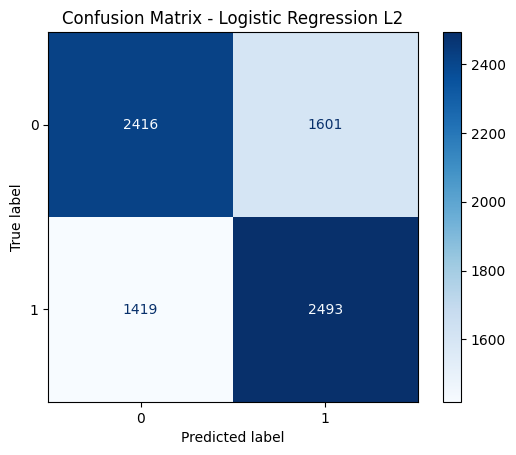

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


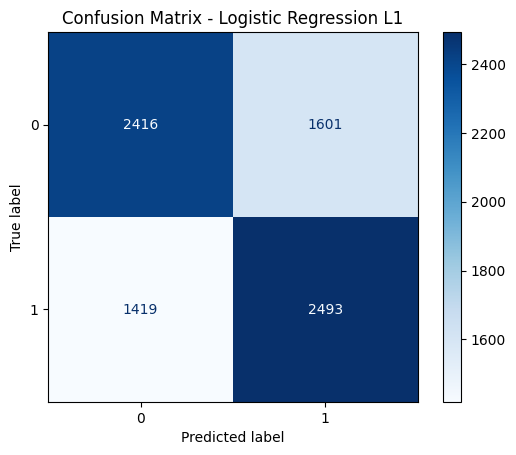

In [75]:
for model, name in [
    (log_l2, "Logistic Regression L2"),
    (log_l1, "Logistic Regression L1")
]:
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

##ROC Curve

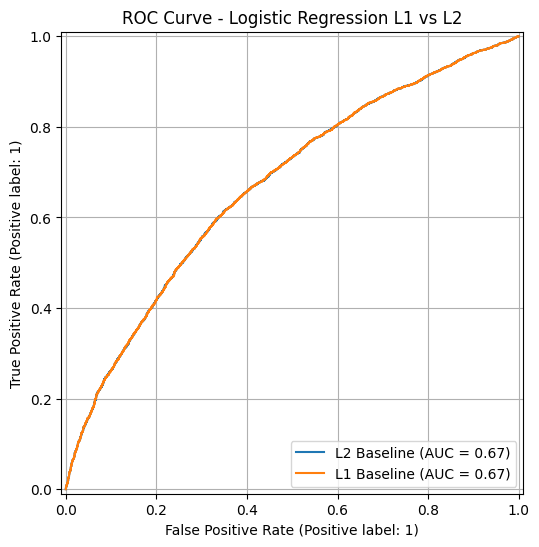

In [76]:
plt.figure(figsize=(8, 6))

for model, name in [
    (log_l2, "L2 Baseline"),
    (log_l1, "L1 Baseline")
]:
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, name=name, ax=plt.gca())

plt.title("ROC Curve - Logistic Regression L1 vs L2")
plt.grid()
plt.show()

##Precision-Recall Curve

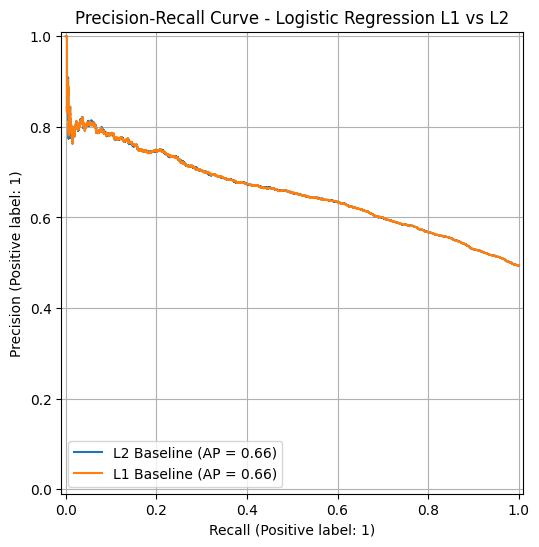

In [77]:
plt.figure(figsize=(8, 6))

for model, name in [
    (log_l2, "L2 Baseline"),
    (log_l1, "L1 Baseline")
]:
    PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, name=name, ax=plt.gca())

plt.title("Precision-Recall Curve - Logistic Regression L1 vs L2")
plt.grid()
plt.show()

##Calibration Curve + Brier Score

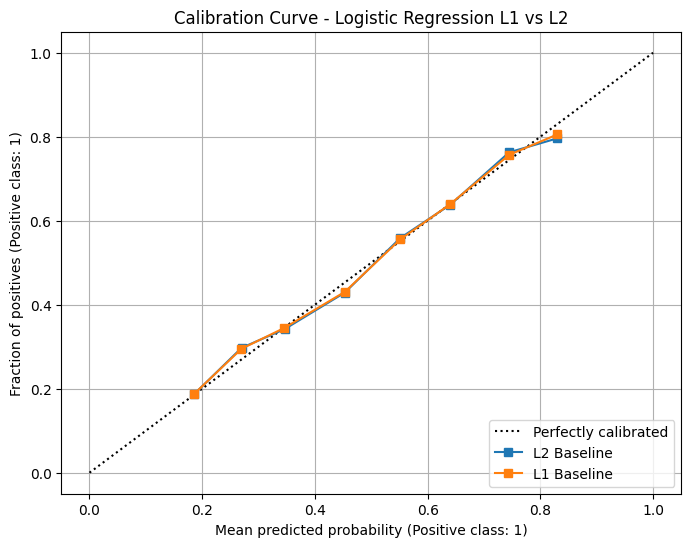

L2 Brier Score: 0.22809886819317698
L1 Brier Score: 0.2280932844424707


In [78]:
plt.figure(figsize=(8, 6))

for model, name in [
    (log_l2, "L2 Baseline"),
    (log_l1, "L1 Baseline")
]:
    CalibrationDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        n_bins=10,
        name=name,
        ax=plt.gca()
    )

plt.title("Calibration Curve - Logistic Regression L1 vs L2")
plt.grid()
plt.show()

print("L2 Brier Score:", results_l2["Brier Score"])
print("L1 Brier Score:", results_l1["Brier Score"])

##GridSearchCV on C, penalty, solver

In [79]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

param_grid = [
    {
        "model__penalty": ["l1"],
        "model__solver": ["liblinear", "saga"],
        "model__C": [0.001, 0.01, 0.1, 1,5,7, 10,20,30,50,70 ,100]
    },
    {
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear", "saga"],
        "model__C": [0.001, 0.01, 0.1, 1,5,7, 10,20,30,50,70 ,100]
    }
]

grid_search = GridSearchCV(
    estimator=log_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

print("Best GridSearchCV Parameters:")
print(grid_search.best_params_)

print("Best CV F1 Score:")
print(grid_search.best_score_)

best_grid_model = grid_search.best_estimator_
results_grid = evaluate_classifier(best_grid_model, X_test_scaled, y_test, "Best Logistic Regression - GridSearchCV")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best GridSearchCV Parameters:
{'model__C': 0.001, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV F1 Score:
0.6403773153435102

========== Best Logistic Regression - GridSearchCV ==========
              precision    recall  f1-score   support

           0       0.64      0.49      0.55      4017
           1       0.58      0.71      0.64      3912

    accuracy                           0.60      7929
   macro avg       0.61      0.60      0.60      7929
weighted avg       0.61      0.60      0.60      7929

                                     Model  Accuracy  Precision   Recall  \
0  Best Logistic Regression - GridSearchCV  0.601211   0.577415  0.71498   

   F1-score  ROC-AUC    PR-AUC  Brier Score       MCC  
0  0.638876  0.64344  0.622018     0.237204  0.210626  


##RandomizedSearchCV

In [80]:
param_dist = [
    {
        "model__penalty": ["l1"],
        "model__solver": ["liblinear", "saga"],
        "model__C": loguniform(0.001, 100)
    },
    {
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear", "saga"],
        "model__C": loguniform(0.001, 100)
    }
]

random_search = RandomizedSearchCV(
    estimator=log_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train_scaled, y_train)

print("Best RandomizedSearchCV Parameters:")
print(random_search.best_params_)

print("Best CV F1 Score:")
print(random_search.best_score_)

best_random_model = random_search.best_estimator_
results_random = evaluate_classifier(best_random_model, X_test_scaled, y_test, "Best Logistic Regression - RandomizedSearchCV")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RandomizedSearchCV Parameters:
{'model__C': np.float64(0.0011649969967638908), 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV F1 Score:
0.6428261822936596

========== Best Logistic Regression - RandomizedSearchCV ==========
              precision    recall  f1-score   support

           0       0.64      0.49      0.56      4017
           1       0.58      0.72      0.64      3912

    accuracy                           0.60      7929
   macro avg       0.61      0.60      0.60      7929
weighted avg       0.61      0.60      0.60      7929

                                           Model  Accuracy  Precision  \
0  Best Logistic Regression - RandomizedSearchCV  0.603229   0.578807   

    Recall  F1-score   ROC-AUC    PR-AUC  Brier Score       MCC  
0  0.71907  0.641359  0.647418  0.628446     0.235929  0.215024  


##Final Comparison Table

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Brier Score,MCC
0,Logistic Regression L2 Baseline,0.630092,0.622836,0.634458,0.628593,0.670284,0.655394,0.228099,0.260279
1,Logistic Regression L1 Baseline,0.629461,0.622362,0.633180,0.627724,0.670299,0.655456,0.228093,0.258999
2,Best Logistic Regression - GridSearchCV,0.601211,0.577415,0.714980,0.638876,0.643440,0.622018,0.237204,0.210626
3,Best Logistic Regression - RandomizedSearchCV,0.603229,0.578807,0.719070,0.641359,0.647418,0.628446,0.235929,0.215024


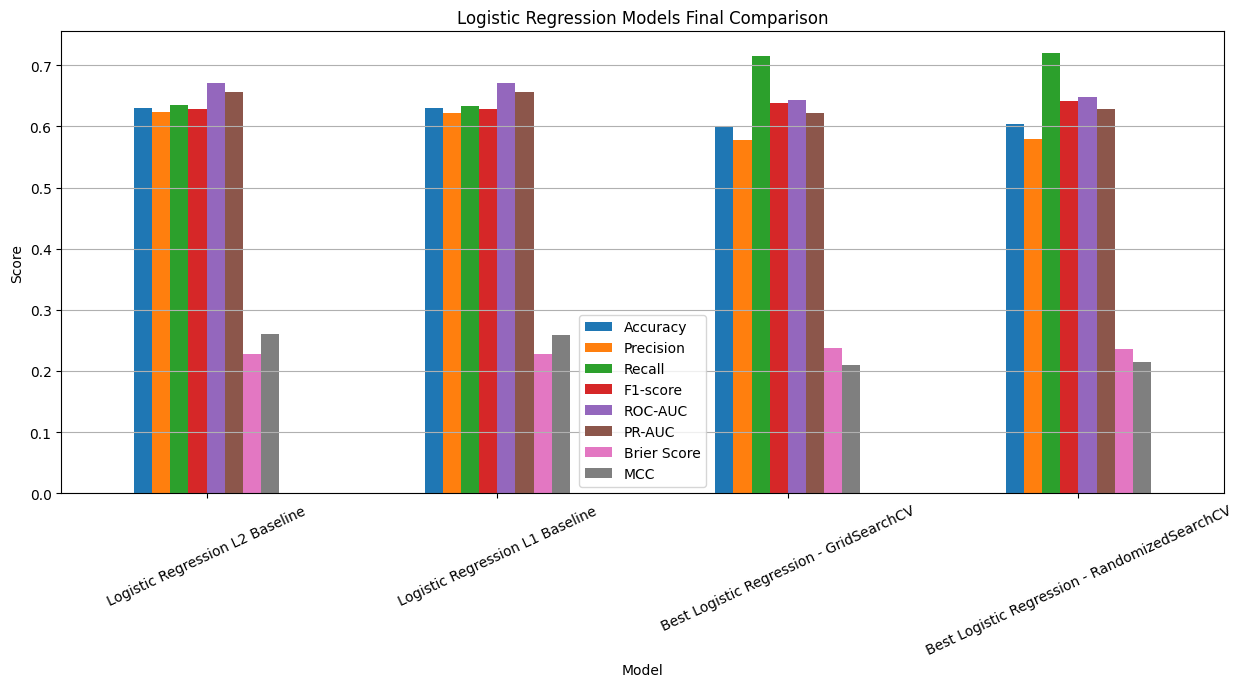

In [81]:
final_comparison = pd.DataFrame([
    results_l2,
    results_l1,
    results_grid,
    results_random
])

display(final_comparison)

final_comparison.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC", "Brier Score", "MCC"
]].plot(kind="bar", figsize=(15, 6))

plt.title("Logistic Regression Models Final Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

##Coefficient Analysis

,Feature,Coefficient,Abs_Coefficient
2,data_channel_is_bus,-0.831811,0.831811
1,data_channel_is_entertainment,-0.830837,0.830837
4,is_weekend,0.813787,0.813787
3,data_channel_is_world,-0.579565,0.579565
7,LDA_02,-0.250489,0.250489
5,LDA_00,0.201345,0.201345
0,n_unique_tokens,-0.188420,0.188420
9,global_subjectivity,0.163837,0.163837
10,global_sentiment_polarity,0.163775,0.163775
14,sentiment_squared,-0.109982,0.109982


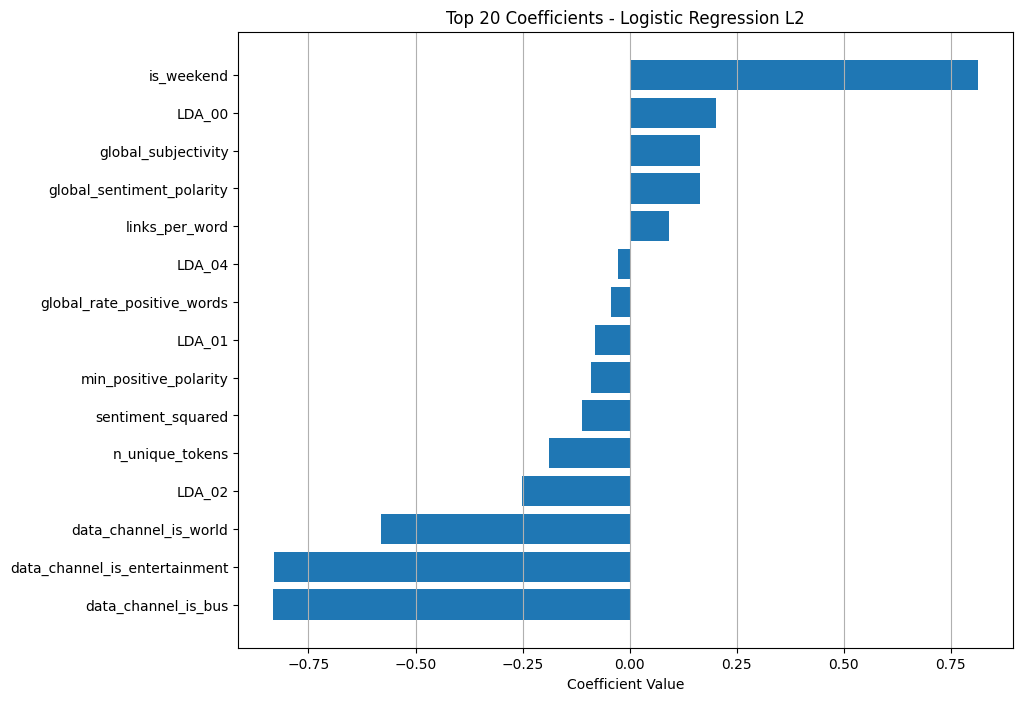

,Feature,Coefficient,Abs_Coefficient
2,data_channel_is_bus,-0.855657,0.855657
1,data_channel_is_entertainment,-0.846323,0.846323
4,is_weekend,0.825324,0.825324
3,data_channel_is_world,-0.598089,0.598089
7,LDA_02,-0.246589,0.246589
5,LDA_00,0.206673,0.206673
0,n_unique_tokens,-0.188105,0.188105
9,global_subjectivity,0.164161,0.164161
10,global_sentiment_polarity,0.162038,0.162038
14,sentiment_squared,-0.108738,0.108738


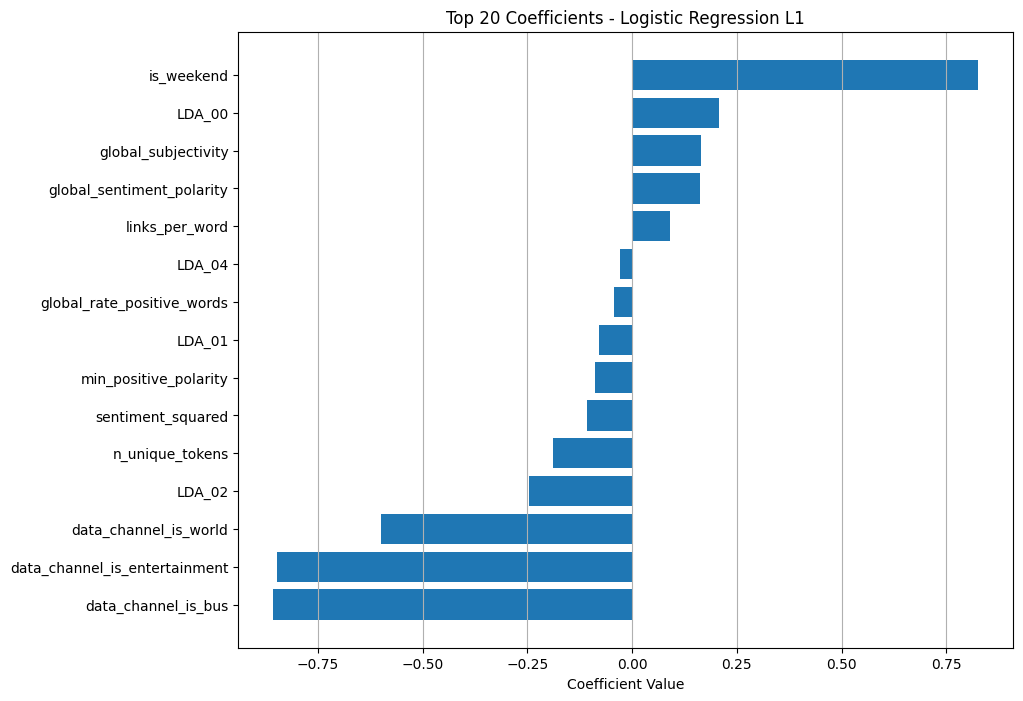

In [83]:
def coefficient_analysis(model, feature_names, model_name):
    coefs = model.named_steps["model"].coef_[0]

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefs,
        "Abs_Coefficient": np.abs(coefs)
    }).sort_values("Abs_Coefficient", ascending=False)

    display(coef_df.head(20))

    plt.figure(figsize=(10, 8))
    top_coef = coef_df.head(20).sort_values("Coefficient")

    plt.barh(top_coef["Feature"], top_coef["Coefficient"])
    plt.title(f"Top 20 Coefficients - {model_name}")
    plt.xlabel("Coefficient Value")
    plt.grid(axis="x")
    plt.show()

    return coef_df


coef_l2 = coefficient_analysis(log_l2, X_train.columns, "Logistic Regression L2")
coef_l1 = coefficient_analysis(log_l1, X_train.columns, "Logistic Regression L1")

##Regularization Effect: L1 vs L2

Number of zero coefficients in L1:
0
Number of zero coefficients in L2:
0


,Model,Zero Coefficients,Non-zero Coefficients
0,L1,0,15
1,L2,0,15


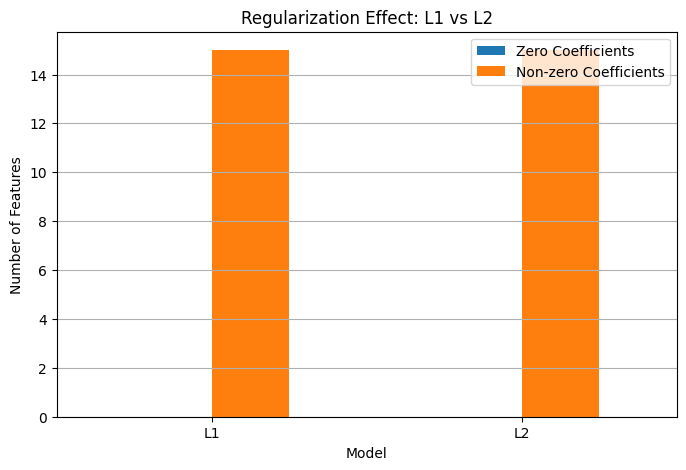

In [84]:
print("Number of zero coefficients in L1:")
print((coef_l1["Coefficient"] == 0).sum())

print("Number of zero coefficients in L2:")
print((coef_l2["Coefficient"] == 0).sum())

reg_effect_df = pd.DataFrame({
    "Model": ["L1", "L2"],
    "Zero Coefficients": [
        (coef_l1["Coefficient"] == 0).sum(),
        (coef_l2["Coefficient"] == 0).sum()
    ],
    "Non-zero Coefficients": [
        (coef_l1["Coefficient"] != 0).sum(),
        (coef_l2["Coefficient"] != 0).sum()
    ]
})

display(reg_effect_df)

reg_effect_df.set_index("Model").plot(kind="bar", figsize=(8, 5))
plt.title("Regularization Effect: L1 vs L2")
plt.ylabel("Number of Features")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

##Learning Curve

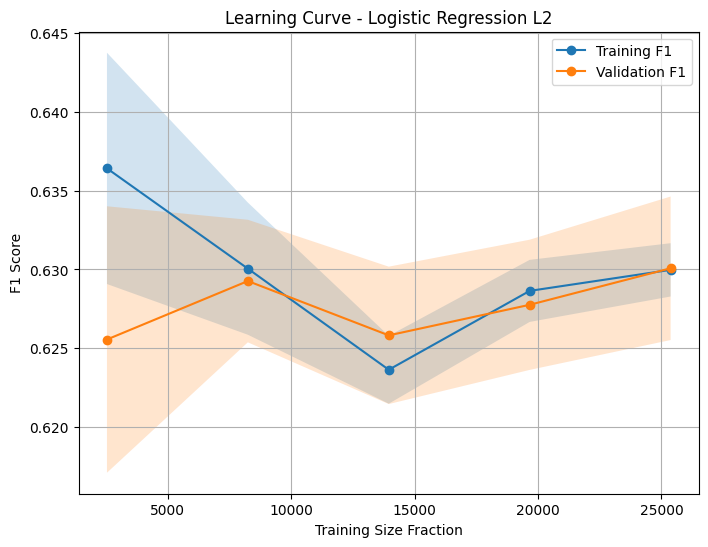

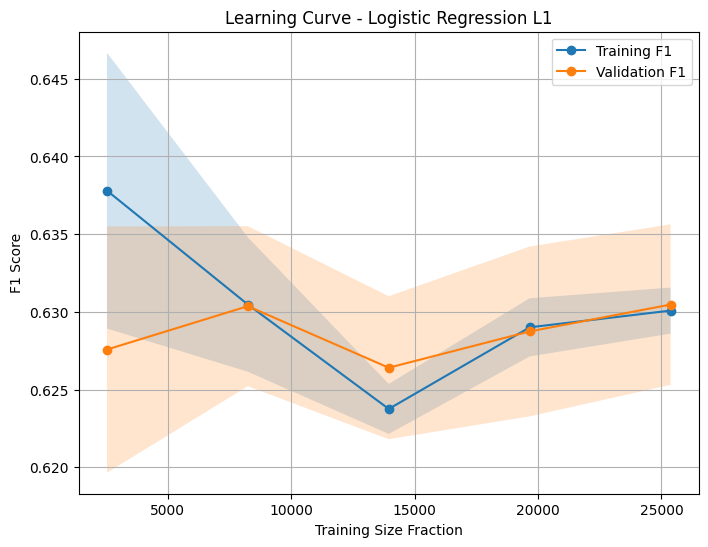

In [85]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

    plt.title(title)
    plt.xlabel("Training Size Fraction")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid()
    plt.show()


plot_learning_curve(log_l2, X_train_scaled, y_train, "Learning Curve - Logistic Regression L2")
plot_learning_curve(log_l1, X_train_scaled, y_train, "Learning Curve - Logistic Regression L1")

##Hyperparameter Heatmap

penalty        l1                  l2                    
solver  liblinear      saga     lbfgs liblinear      saga
C                                                        
0.001    0.640377  0.632203  0.629416  0.630199  0.629569
0.010    0.636056  0.633750  0.630537  0.630547  0.630540
0.100    0.630973  0.630695  0.630478  0.630517  0.630517
1.000    0.630604  0.630491  0.630389  0.630402  0.630402
5.000    0.630444  0.630401  0.630365  0.630421  0.630421
7.000    0.630401  0.630358  0.630365  0.630421  0.630421
10.000   0.630401  0.630358  0.630365  0.630421  0.630421
20.000   0.630358  0.630402  0.630365  0.630421  0.630421
30.000   0.630358  0.630421  0.630365  0.630421  0.630421
50.000   0.630378  0.630421  0.630365  0.630421  0.630421
70.000   0.630378  0.630421  0.630365  0.630421  0.630421
100.000  0.630378  0.630421  0.630365  0.630421  0.630421

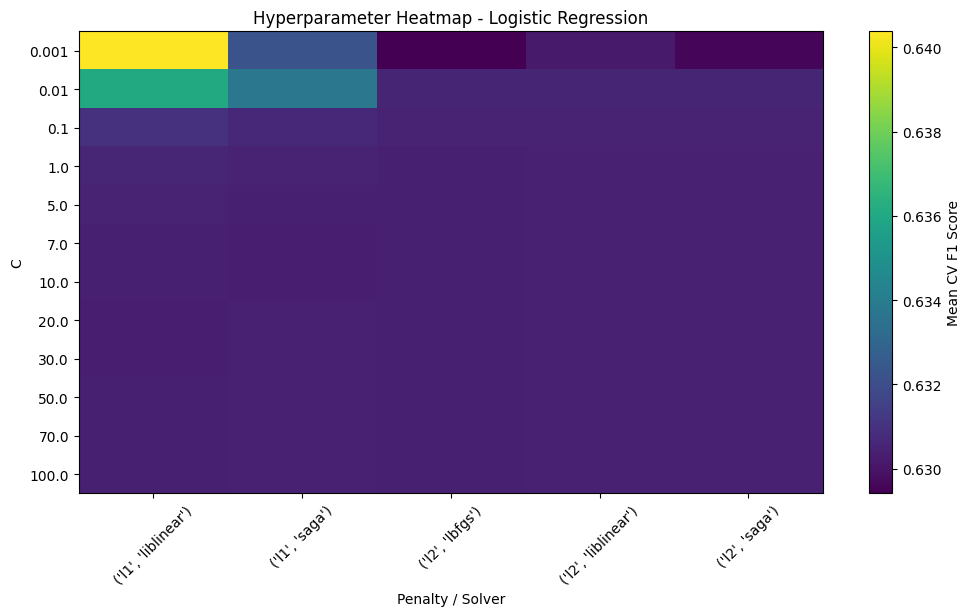

In [86]:
grid_results = pd.DataFrame(grid_search.cv_results_)

heatmap_data = grid_results.copy()
heatmap_data["C"] = heatmap_data["param_model__C"].astype(float)
heatmap_data["penalty"] = heatmap_data["param_model__penalty"].astype(str)
heatmap_data["solver"] = heatmap_data["param_model__solver"].astype(str)

pivot_table = heatmap_data.pivot_table(
    values="mean_test_score",
    index="C",
    columns=["penalty", "solver"]
)

display(pivot_table)

plt.figure(figsize=(12, 6))
plt.imshow(pivot_table, aspect="auto")
plt.colorbar(label="Mean CV F1 Score")
plt.xticks(range(len(pivot_table.columns)), [str(col) for col in pivot_table.columns], rotation=45)
plt.yticks(range(len(pivot_table.index)), pivot_table.index)
plt.title("Hyperparameter Heatmap - Logistic Regression")
plt.xlabel("Penalty / Solver")
plt.ylabel("C")
plt.show()

##Robustness Test 1: Noise Injection

,Noise Level,Accuracy,F1-score,ROC-AUC
0,Low Noise,0.601841,0.639076,0.642440
1,Medium Noise,0.602094,0.638644,0.635447
2,High Noise,0.598688,0.629051,0.631401


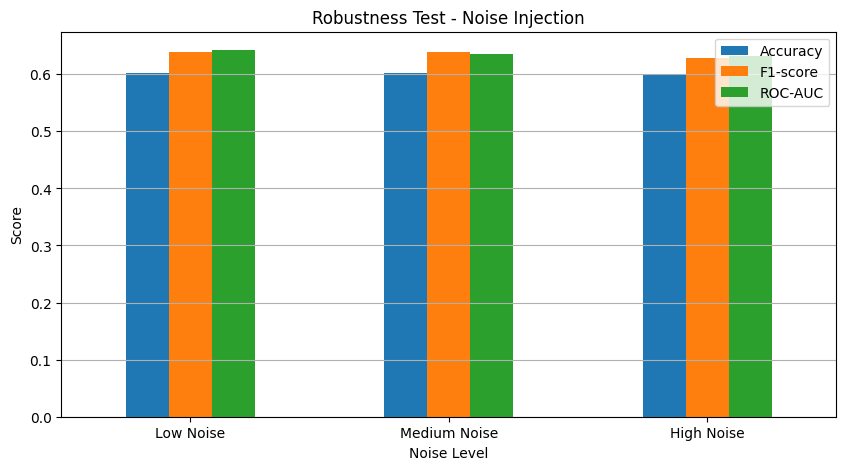

In [88]:
def noise_injection_test(model, X_train_scaled, X_test_scaled, y_train, y_test, feature_names):
    noise_levels = {
        "Low Noise": 0.01,
        "Medium Noise": 0.05,
        "High Noise": 0.10
    }

    results = []

    X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

    for noise_name, noise_std in noise_levels.items():
        X_train_noisy = X_train_df.copy()
        X_test_noisy = X_test_df.copy()

        numeric_cols = X_train_noisy.select_dtypes(include=np.number).columns

        X_train_noisy[numeric_cols] = X_train_noisy[numeric_cols] + np.random.normal(
            0, noise_std, X_train_noisy[numeric_cols].shape
        )

        X_test_noisy[numeric_cols] = X_test_noisy[numeric_cols] + np.random.normal(
            0, noise_std, X_test_noisy[numeric_cols].shape
        )

        model.fit(X_train_noisy, y_train)
        y_pred = model.predict(X_test_noisy)
        y_proba = model.predict_proba(X_test_noisy)[:, 1]

        results.append({
            "Noise Level": noise_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba)
        })

    return pd.DataFrame(results)


noise_results = noise_injection_test(best_grid_model, X_train_scaled, X_test_scaled, y_train, y_test, X_train.columns)
display(noise_results)

noise_results.set_index("Noise Level").plot(kind="bar", figsize=(10, 5))
plt.title("Robustness Test - Noise Injection")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

##Robustness Test 2: Feature Removal

In [91]:
important_features = coef_l2.head(10)["Feature"].tolist()

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

X_train_removed = X_train_scaled_df.drop(columns=important_features)
X_test_removed = X_test_scaled_df.drop(columns=important_features)

feature_removed_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                penalty="l2", solver="lbfgs", C=1.0, max_iter=5000, random_state=42
            ),
        ),
    ]
)

feature_removed_model.fit(X_train_removed, y_train)


model_name = "Logistic Regression After Removing Top Features"
y_pred = feature_removed_model.predict(X_test_removed)
y_proba = feature_removed_model.predict_proba(X_test_removed)[:, 1]

results_removed = {
    "Model": model_name,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba),
    "Brier Score": brier_score_loss(y_test, y_proba),
    "MCC": matthews_corrcoef(y_test, y_pred)
}

print(f"\n========== {model_name} ==========")
print(classification_report(y_test, y_pred))
print(pd.DataFrame([results_removed]))


========== Logistic Regression After Removing Top Features ==========
              precision    recall  f1-score   support

           0       0.57      0.63      0.60      4017
           1       0.57      0.52      0.54      3912

    accuracy                           0.57      7929
   macro avg       0.57      0.57      0.57      7929
weighted avg       0.57      0.57      0.57      7929

                                             Model  Accuracy  Precision  \
0  Logistic Regression After Removing Top Features  0.572203   0.573906   

     Recall  F1-score   ROC-AUC    PR-AUC  Brier Score       MCC  
0  0.516104  0.543472  0.586401  0.561461     0.244808  0.143843  


## Robustness Test 3: Reduced Training Data

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist

,Training Data Size,Accuracy,F1-score,ROC-AUC
0,10%,0.625173,0.617602,0.666698
1,30%,0.628326,0.631671,0.669820
2,50%,0.629714,0.628543,0.670295
3,100%,0.629461,0.627724,0.670288


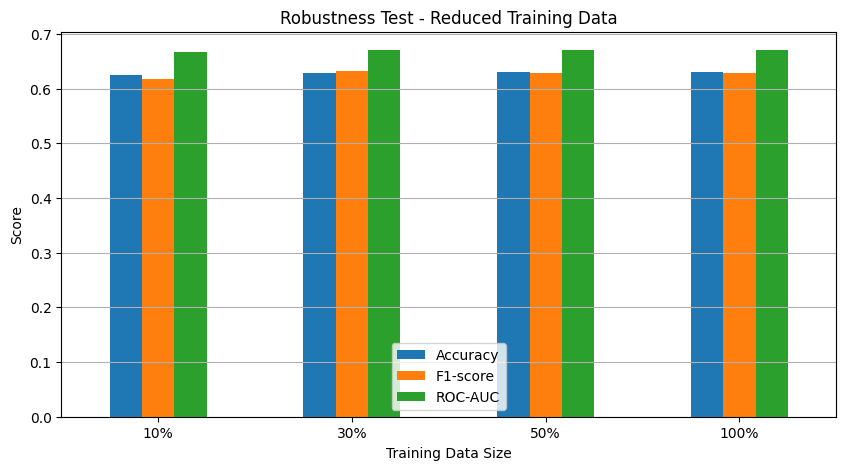

In [94]:
train_sizes_list = [0.1, 0.3, 0.5, 1.0]
reduced_results = []


X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

for size in train_sizes_list:
    if size < 1.0:
        sample_idx = X_train_scaled_df.sample(frac=size, random_state=42).index
        X_subset = X_train_scaled_df.loc[sample_idx]
        y_subset = y_train.loc[sample_idx]
    else:
        X_subset = X_train_scaled_df
        y_subset = y_train


    model = Pipeline([
        ("model", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            C=1.0,
            max_iter=5000,
            random_state=42
        ))
    ])

    model.fit(X_subset, y_subset)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    reduced_results.append({
        "Training Data Size": f"{int(size * 100)}%",
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

reduced_results_df = pd.DataFrame(reduced_results)
display(reduced_results_df)

reduced_results_df.set_index("Training Data Size").plot(kind="bar", figsize=(10, 5))
plt.title("Robustness Test - Reduced Training Data")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

##Robustness Test 4: Outlier Sensitivity

In [96]:
X_train_outlier_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_outlier_df = pd.DataFrame(X_test_scaled, columns=X_train.columns, index=X_test.index)

numeric_cols = X_train_outlier_df.select_dtypes(include=np.number).columns

outlier_fraction = 0.01
n_outliers = int(len(X_train_outlier_df) * outlier_fraction)

np.random.seed(42)
outlier_indices = np.random.choice(X_train_outlier_df.index, size=n_outliers, replace=False)

X_train_modified_for_outlier = X_train_outlier_df.copy()
for col in numeric_cols:
    X_train_modified_for_outlier.loc[outlier_indices, col] = X_train_modified_for_outlier[col].mean() + 10 * X_train_modified_for_outlier[col].std()

outlier_model = Pipeline([

    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=1.0,
        max_iter=5000,
        random_state=42
    ))
])

outlier_model.fit(X_train_modified_for_outlier, y_train)


model_name = "Logistic Regression Outlier Sensitivity"
y_pred = outlier_model.predict(X_test_outlier_df)
y_proba = outlier_model.predict_proba(X_test_outlier_df)[:, 1]

results_outlier = {
    "Model": model_name,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba),
    "Brier Score": brier_score_loss(y_test, y_proba),
    "MCC": matthews_corrcoef(y_test, y_pred)
}

print(f"\n========== {model_name} ==========")
print(classification_report(y_test, y_pred))
print(pd.DataFrame([results_outlier]))


========== Logistic Regression Outlier Sensitivity ==========
              precision    recall  f1-score   support

           0       0.63      0.64      0.63      4017
           1       0.62      0.61      0.62      3912

    accuracy                           0.63      7929
   macro avg       0.62      0.62      0.62      7929
weighted avg       0.63      0.63      0.63      7929

                                     Model  Accuracy  Precision    Recall  \
0  Logistic Regression Outlier Sensitivity  0.625047   0.621349  0.614519   

   F1-score   ROC-AUC    PR-AUC  Brier Score      MCC  
0  0.617915  0.666031  0.652959     0.229068  0.24987  


##Final Logistic Regression Robustness Summary

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Brier Score,MCC
0,Best Logistic Regression - GridSearchCV,0.601211,0.577415,0.714980,0.638876,0.643440,0.622018,0.237204,0.210626
1,Logistic Regression After Removing Top Features,0.572203,0.573906,0.516104,0.543472,0.586401,0.561461,0.244808,0.143843
2,Logistic Regression Outlier Sensitivity,0.625047,0.621349,0.614519,0.617915,0.666031,0.652959,0.229068,0.249870


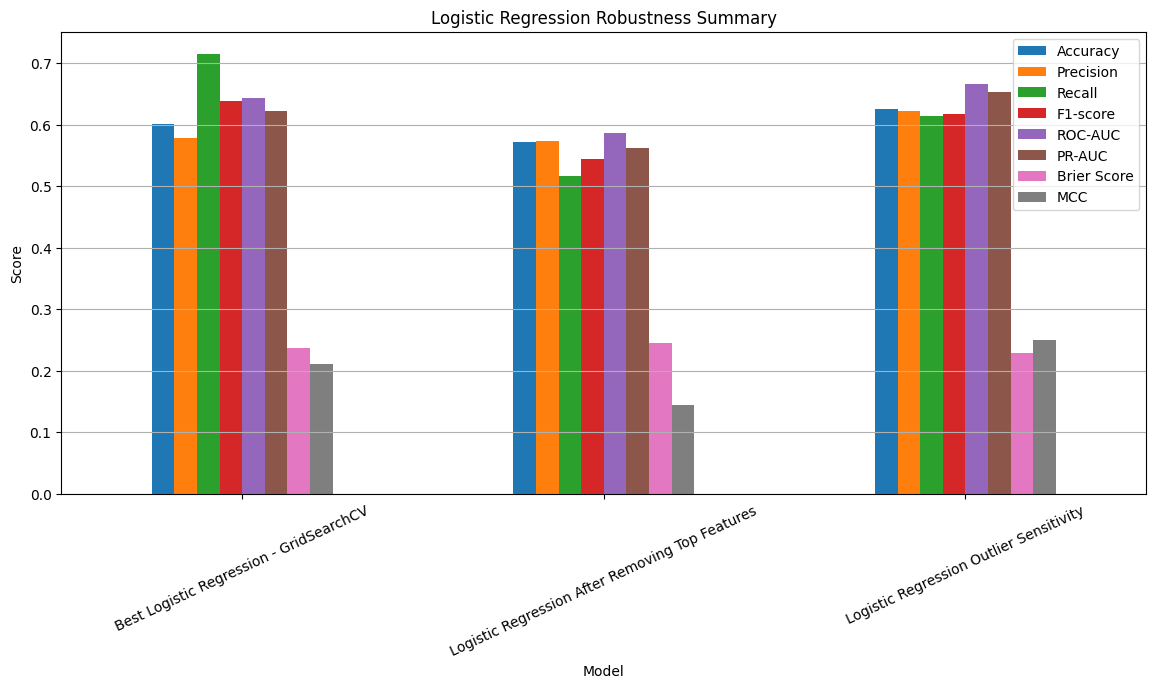

In [97]:
robustness_summary = pd.DataFrame([
    results_grid,
    results_removed,
    results_outlier
])

display(robustness_summary)

robustness_summary.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC", "Brier Score", "MCC"
]].plot(kind="bar", figsize=(14, 6))

plt.title("Logistic Regression Robustness Summary")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()